# Complete Ensemble EMD with Adaptive Noise (CEEMDAN)

**CEEMDAN** keeps the noise-assisted idea of EEMD, but changes *when* and
*which* noise is added so that the decomposition becomes **complete**:

$$
x[n] = \sum_{k=1}^{K}\widetilde{\mathrm{IMF}}_k[n] + R[n].
$$

Key differences vs EEMD (Torres *et al.*, ICASSP 2011):

- a **unique residue** is updated after each mode;
- at stage $k$, one adds a scaled **EMD mode of the noise**
  $\varepsilon_k\, E_k(w_i)$, not raw white noise;
- only the **first** EMD mode of each noisy residue is extracted, then averaged.

This yields exact reconstruction, better spectral separation, and typically
fewer sifting iterations than plain EEMD.

**Reference**

> M. E. Torres, M. A. Colominas, G. Schlotthauer, P. Flandrin.  
> *A Complete Ensemble Empirical Mode Decomposition with Adaptive Noise.*  
> IEEE ICASSP, 2011, pp. 4144–4147.

This notebook uses `pysdkit.CEEMDAN`.

## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "examples":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path and (ROOT / "pysdkit").exists():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import CEEMDAN, EEMD, EMD
from pysdkit.data import test_emd
from pysdkit.plot import plot_IMFs, plot_IMFs_amplitude_spectra

print(CEEMDAN())

Complete Ensemble Empirical Mode Decomposition with Adaptive Noise (CEEMDAN)


## 2. Algorithm principles

### 2.1 What EEMD leaves unfinished

EEMD averages full EMD decompositions of $x+w_i$.  Two issues remain:

1. residual ensemble noise → incomplete reconstruction;
2. different trials may produce **different numbers of modes**.

### 2.2 CEEMDAN idea

Let $E_j(\cdot)$ be the operator that returns the $j$-th IMF of EMD, and let
$w_i\sim\mathcal{N}(0,1)$.  With a unique residue chain:

$$
\begin{aligned}
\widetilde{\mathrm{IMF}}_1
&= \frac{1}{I}\sum_{i=1}^{I} E_1\!\big(x+\varepsilon_0 w_i\big),\\
r_1 &= x - \widetilde{\mathrm{IMF}}_1,\\
\widetilde{\mathrm{IMF}}_{k+1}
&= \frac{1}{I}\sum_{i=1}^{I} E_1\!\big(r_k + \varepsilon_k E_k(w_i)\big),\\
r_{k+1} &= r_k - \widetilde{\mathrm{IMF}}_{k+1}.
\end{aligned}
$$

Stop when $r_K$ is no longer an IMF (too few extrema / amplitude / power).
Then $R=r_K$ and Eq. (5) of the paper holds exactly.

### 2.3 Adaptive noise

Adding $E_k(w_i)$ (an IMF of noise) rather than raw $w_i$ injects energy at the
**current scale**, which improves mode separation and reduces the number of
sifts.

## 3. Demo signals

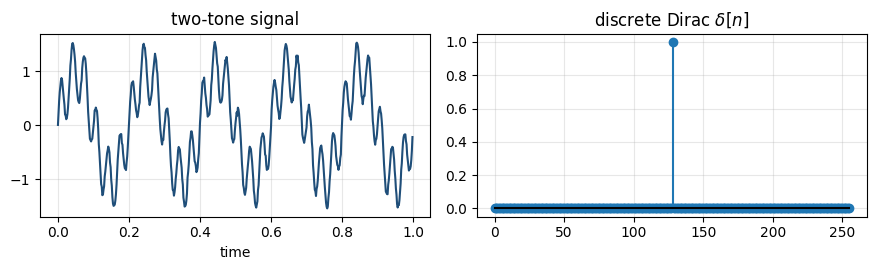

In [2]:
# (A) two-tone + mild noise  — clear scale separation
n = 600
t = np.linspace(0.0, 1.0, n, endpoint=False)
tone = np.sin(2 * np.pi * 5 * t) + 0.55 * np.sin(2 * np.pi * 30 * t)
tone += 0.03 * np.random.default_rng(0).standard_normal(n)

# (B) discrete Dirac impulse — stress test from Torres et al. (Fig. 1)
impulse = np.zeros(256)
impulse[128] = 1.0

fig, axes = plt.subplots(1, 2, figsize=(9, 2.8))
axes[0].plot(t, tone, color="#1f4e79")
axes[0].set_title("two-tone signal")
axes[0].set_xlabel("time")
axes[1].stem(impulse, linefmt="C0-", markerfmt="C0o", basefmt="k-")
axes[1].set_title(r"discrete Dirac $\delta[n]$")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Workflow on the two-tone signal

We walk through the first two stages conceptually, then run the full algorithm.

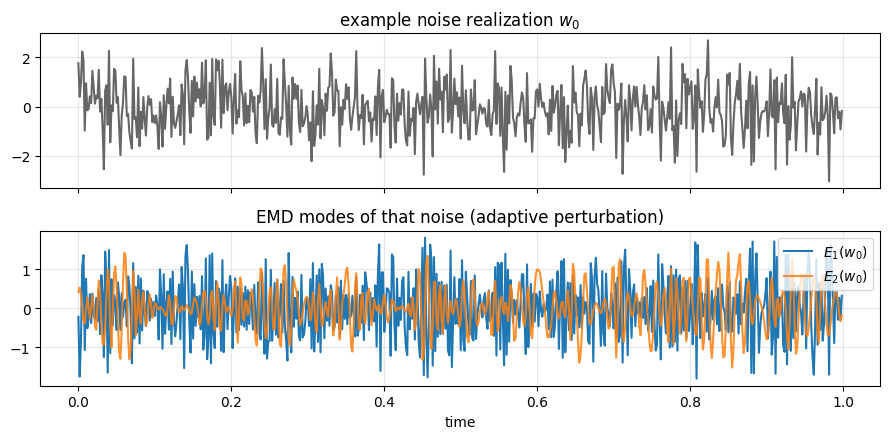

In [3]:
ceemdan = CEEMDAN(
    trials=30,
    epsilon=0.05,
    noise_scale=1.0,
    max_imfs=4,
    random_seed=0,
)

# Pre-decompose noise (as in the implementation / paper)
noises = ceemdan._generate_noise(ceemdan.noise_scale, size=(ceemdan.trials, n))
noise_imfs = [EMD(max_imfs=-1).fit_transform(w) for w in noises[:6]]  # preview only

fig, axes = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True)
axes[0].plot(t, noises[0, :], color="0.4")
axes[0].set_title(r"example noise realization $w_0$")
axes[1].plot(t, noise_imfs[0][0], label=r"$E_1(w_0)$")
if noise_imfs[0].shape[0] > 1:
    axes[1].plot(t, noise_imfs[0][1], label=r"$E_2(w_0)$", alpha=0.85)
axes[1].legend(loc="upper right")
axes[1].set_title("EMD modes of that noise (adaptive perturbation)")
axes[1].set_xlabel("time")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

cIMFs (+ residue): (5, 600)
complete reconstruction error: 4.440892098500626e-16


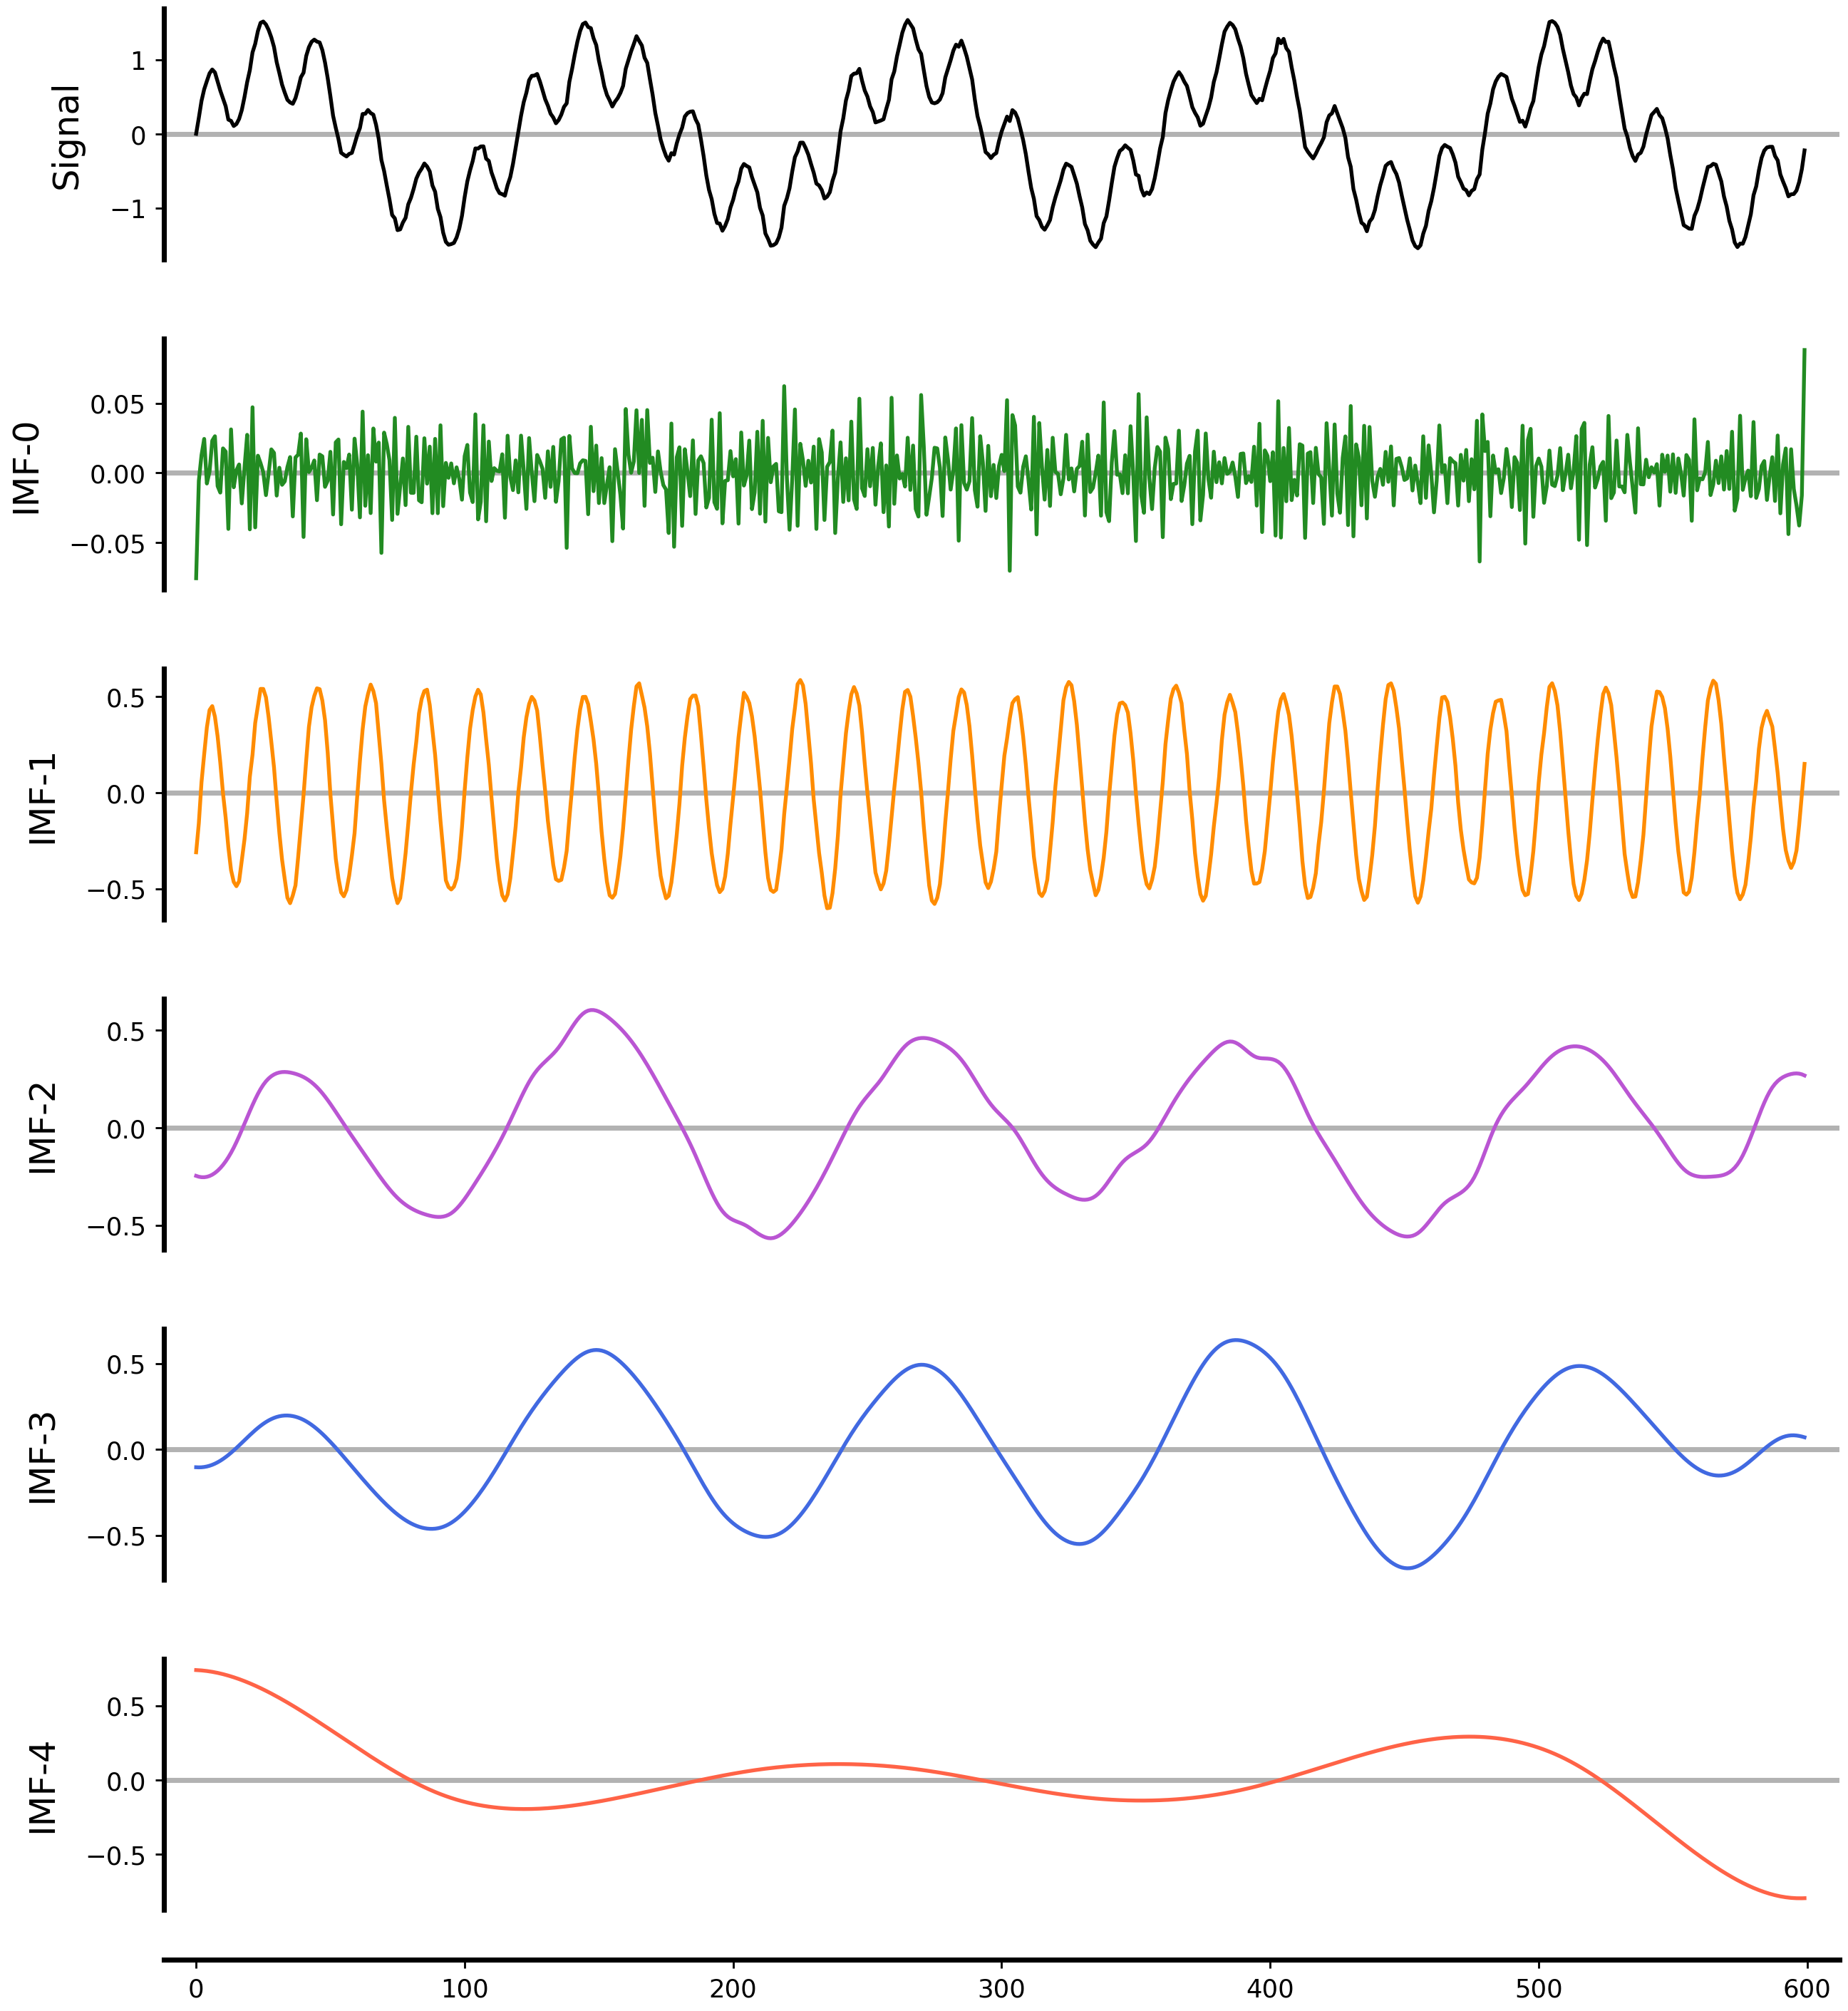

In [4]:
imfs = ceemdan.fit_transform(tone, time=t)
recon = imfs.sum(axis=0)

print("cIMFs (+ residue):", imfs.shape)
print("complete reconstruction error:", float(np.max(np.abs(tone - recon))))

plot_IMFs(tone, imfs)
plt.show()

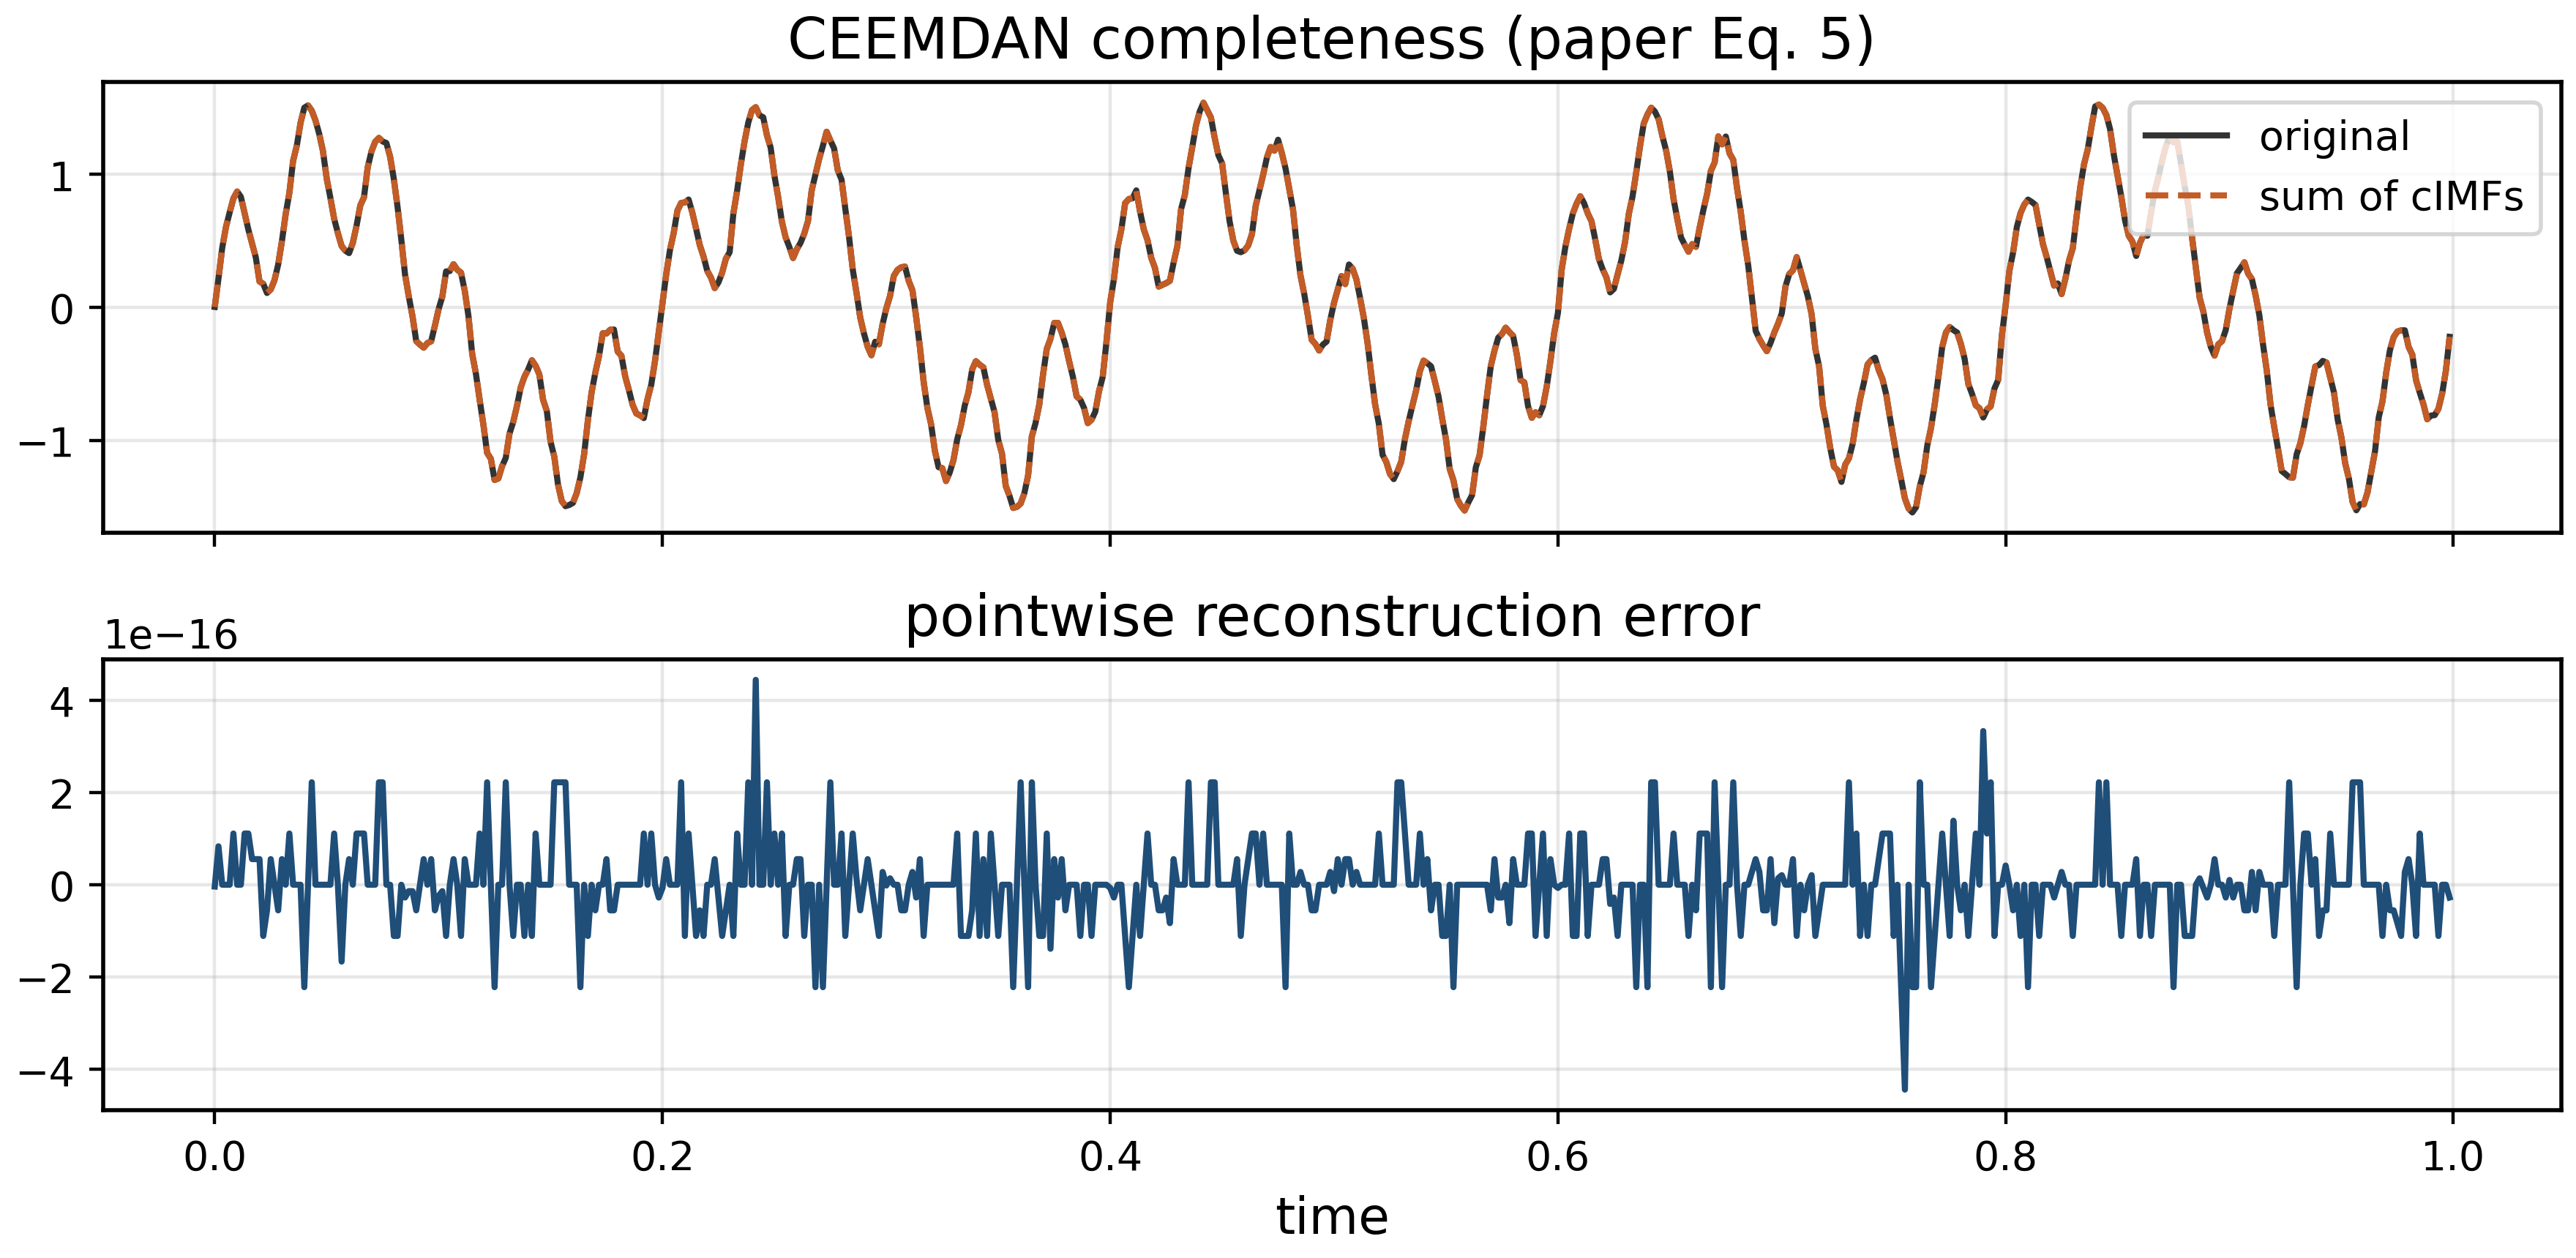

run classic


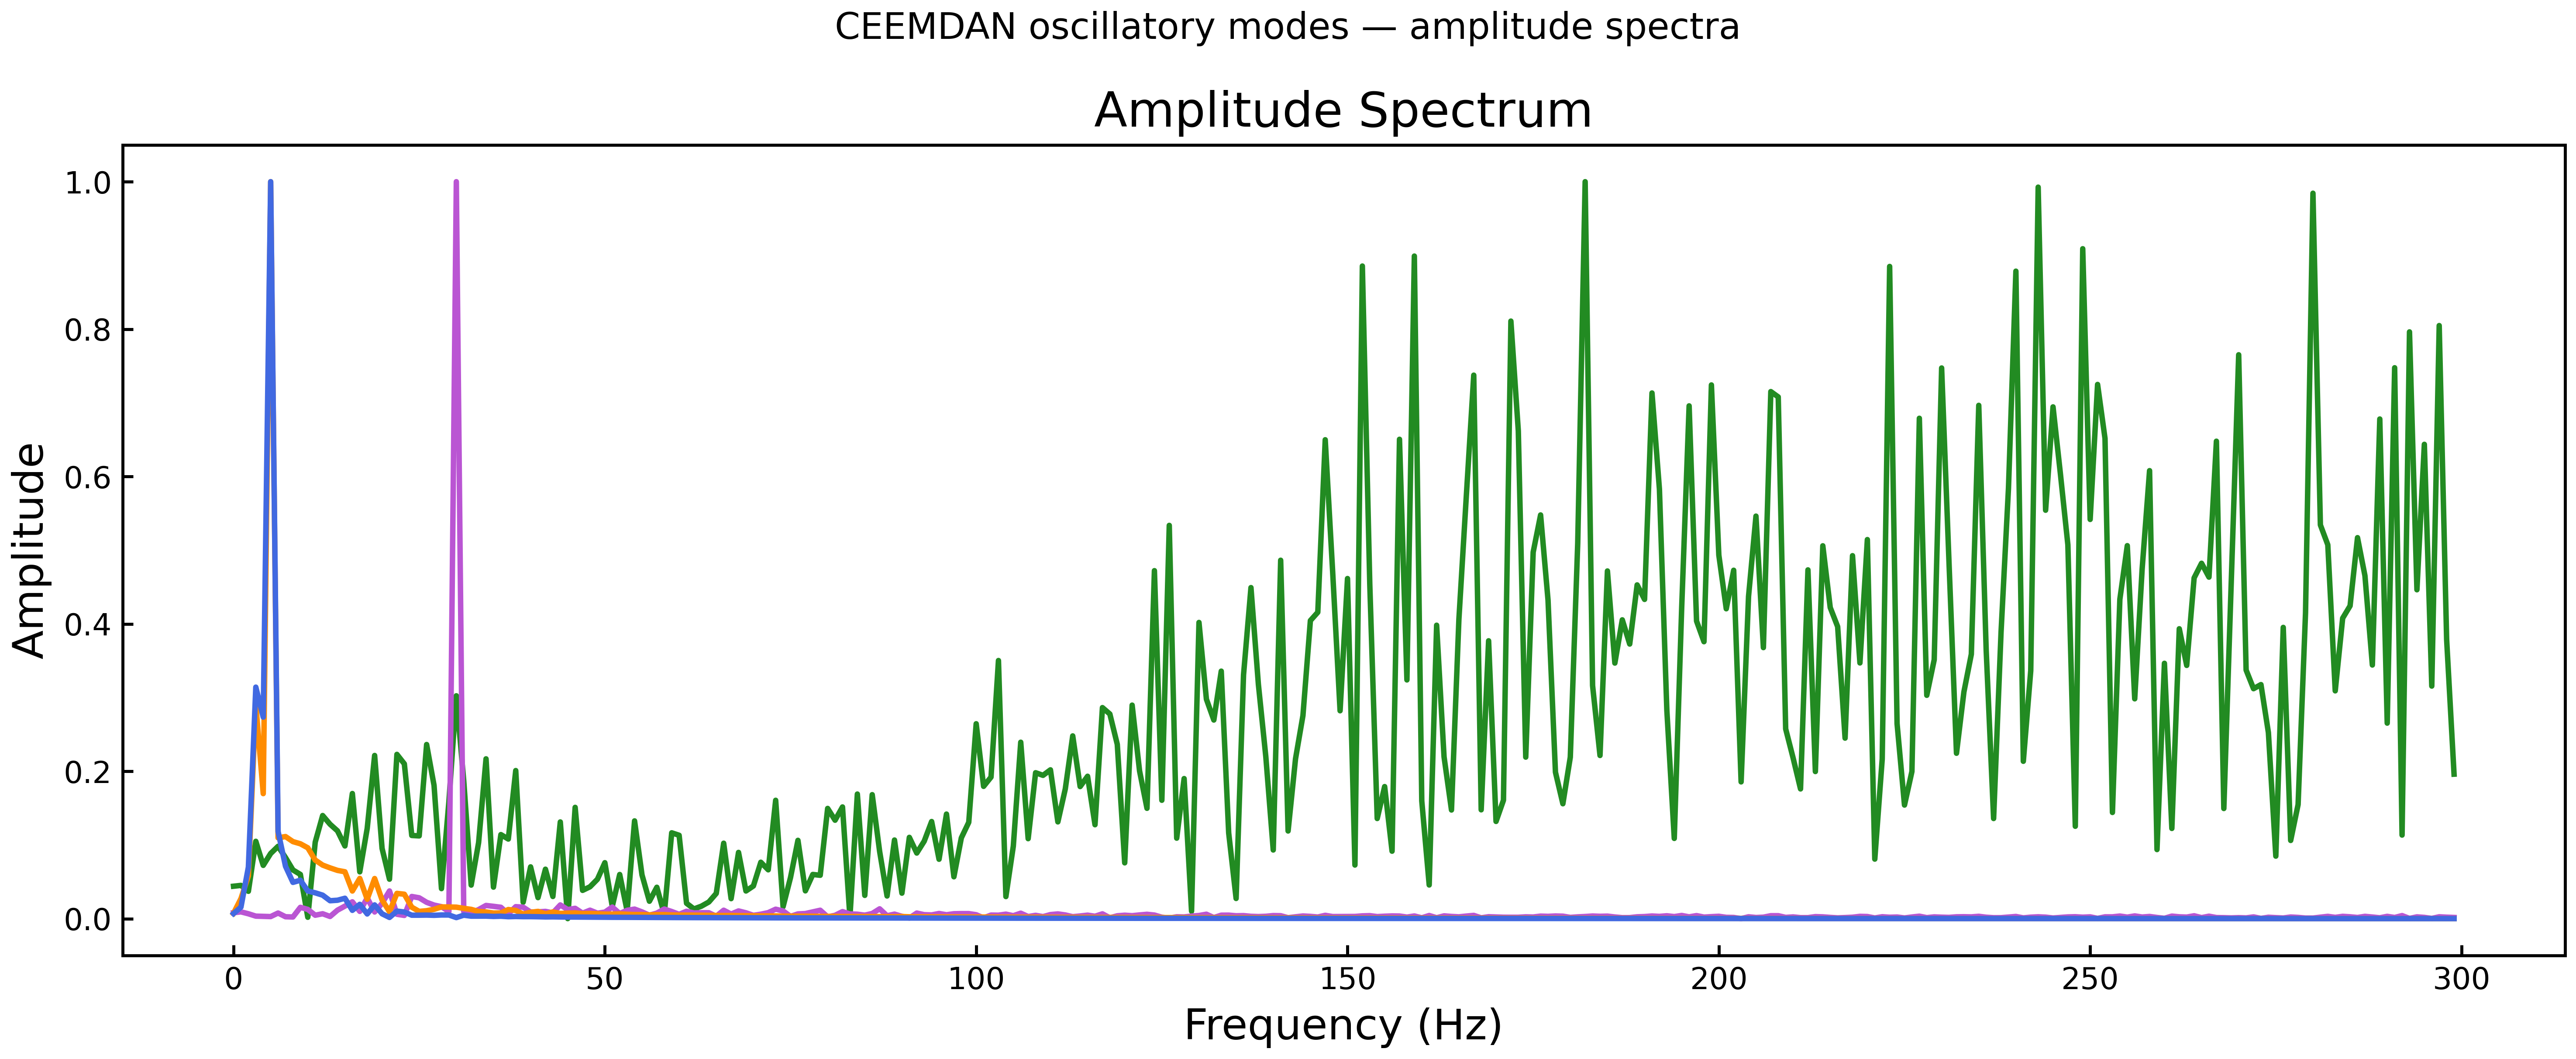

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True)
axes[0].plot(t, tone, label="original", color="0.2")
axes[0].plot(t, recon, "--", label="sum of cIMFs", color="#c45c26")
axes[0].legend(loc="upper right")
axes[0].set_title("CEEMDAN completeness (paper Eq. 5)")
axes[0].grid(True, alpha=0.3)
axes[1].plot(t, tone - recon, color="#1f4e79")
axes[1].set_title("pointwise reconstruction error")
axes[1].set_xlabel("time")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plot_IMFs_amplitude_spectra(imfs[:-1])
plt.suptitle("CEEMDAN oscillatory modes — amplitude spectra")
plt.tight_layout()
plt.show()

## 5. Dirac impulse: CEEMDAN vs EEMD

Following Fig. 1 of Torres *et al.*, CEEMDAN usually needs fewer modes and
reconstructs exactly, while EEMD leaves a visible residual.

CEEMDAN modes: 7 | recon err: 2.220446049250313e-16
EEMD modes: 8 | mean-only recon err: 0.010390273687127135 | with residue: 0.0


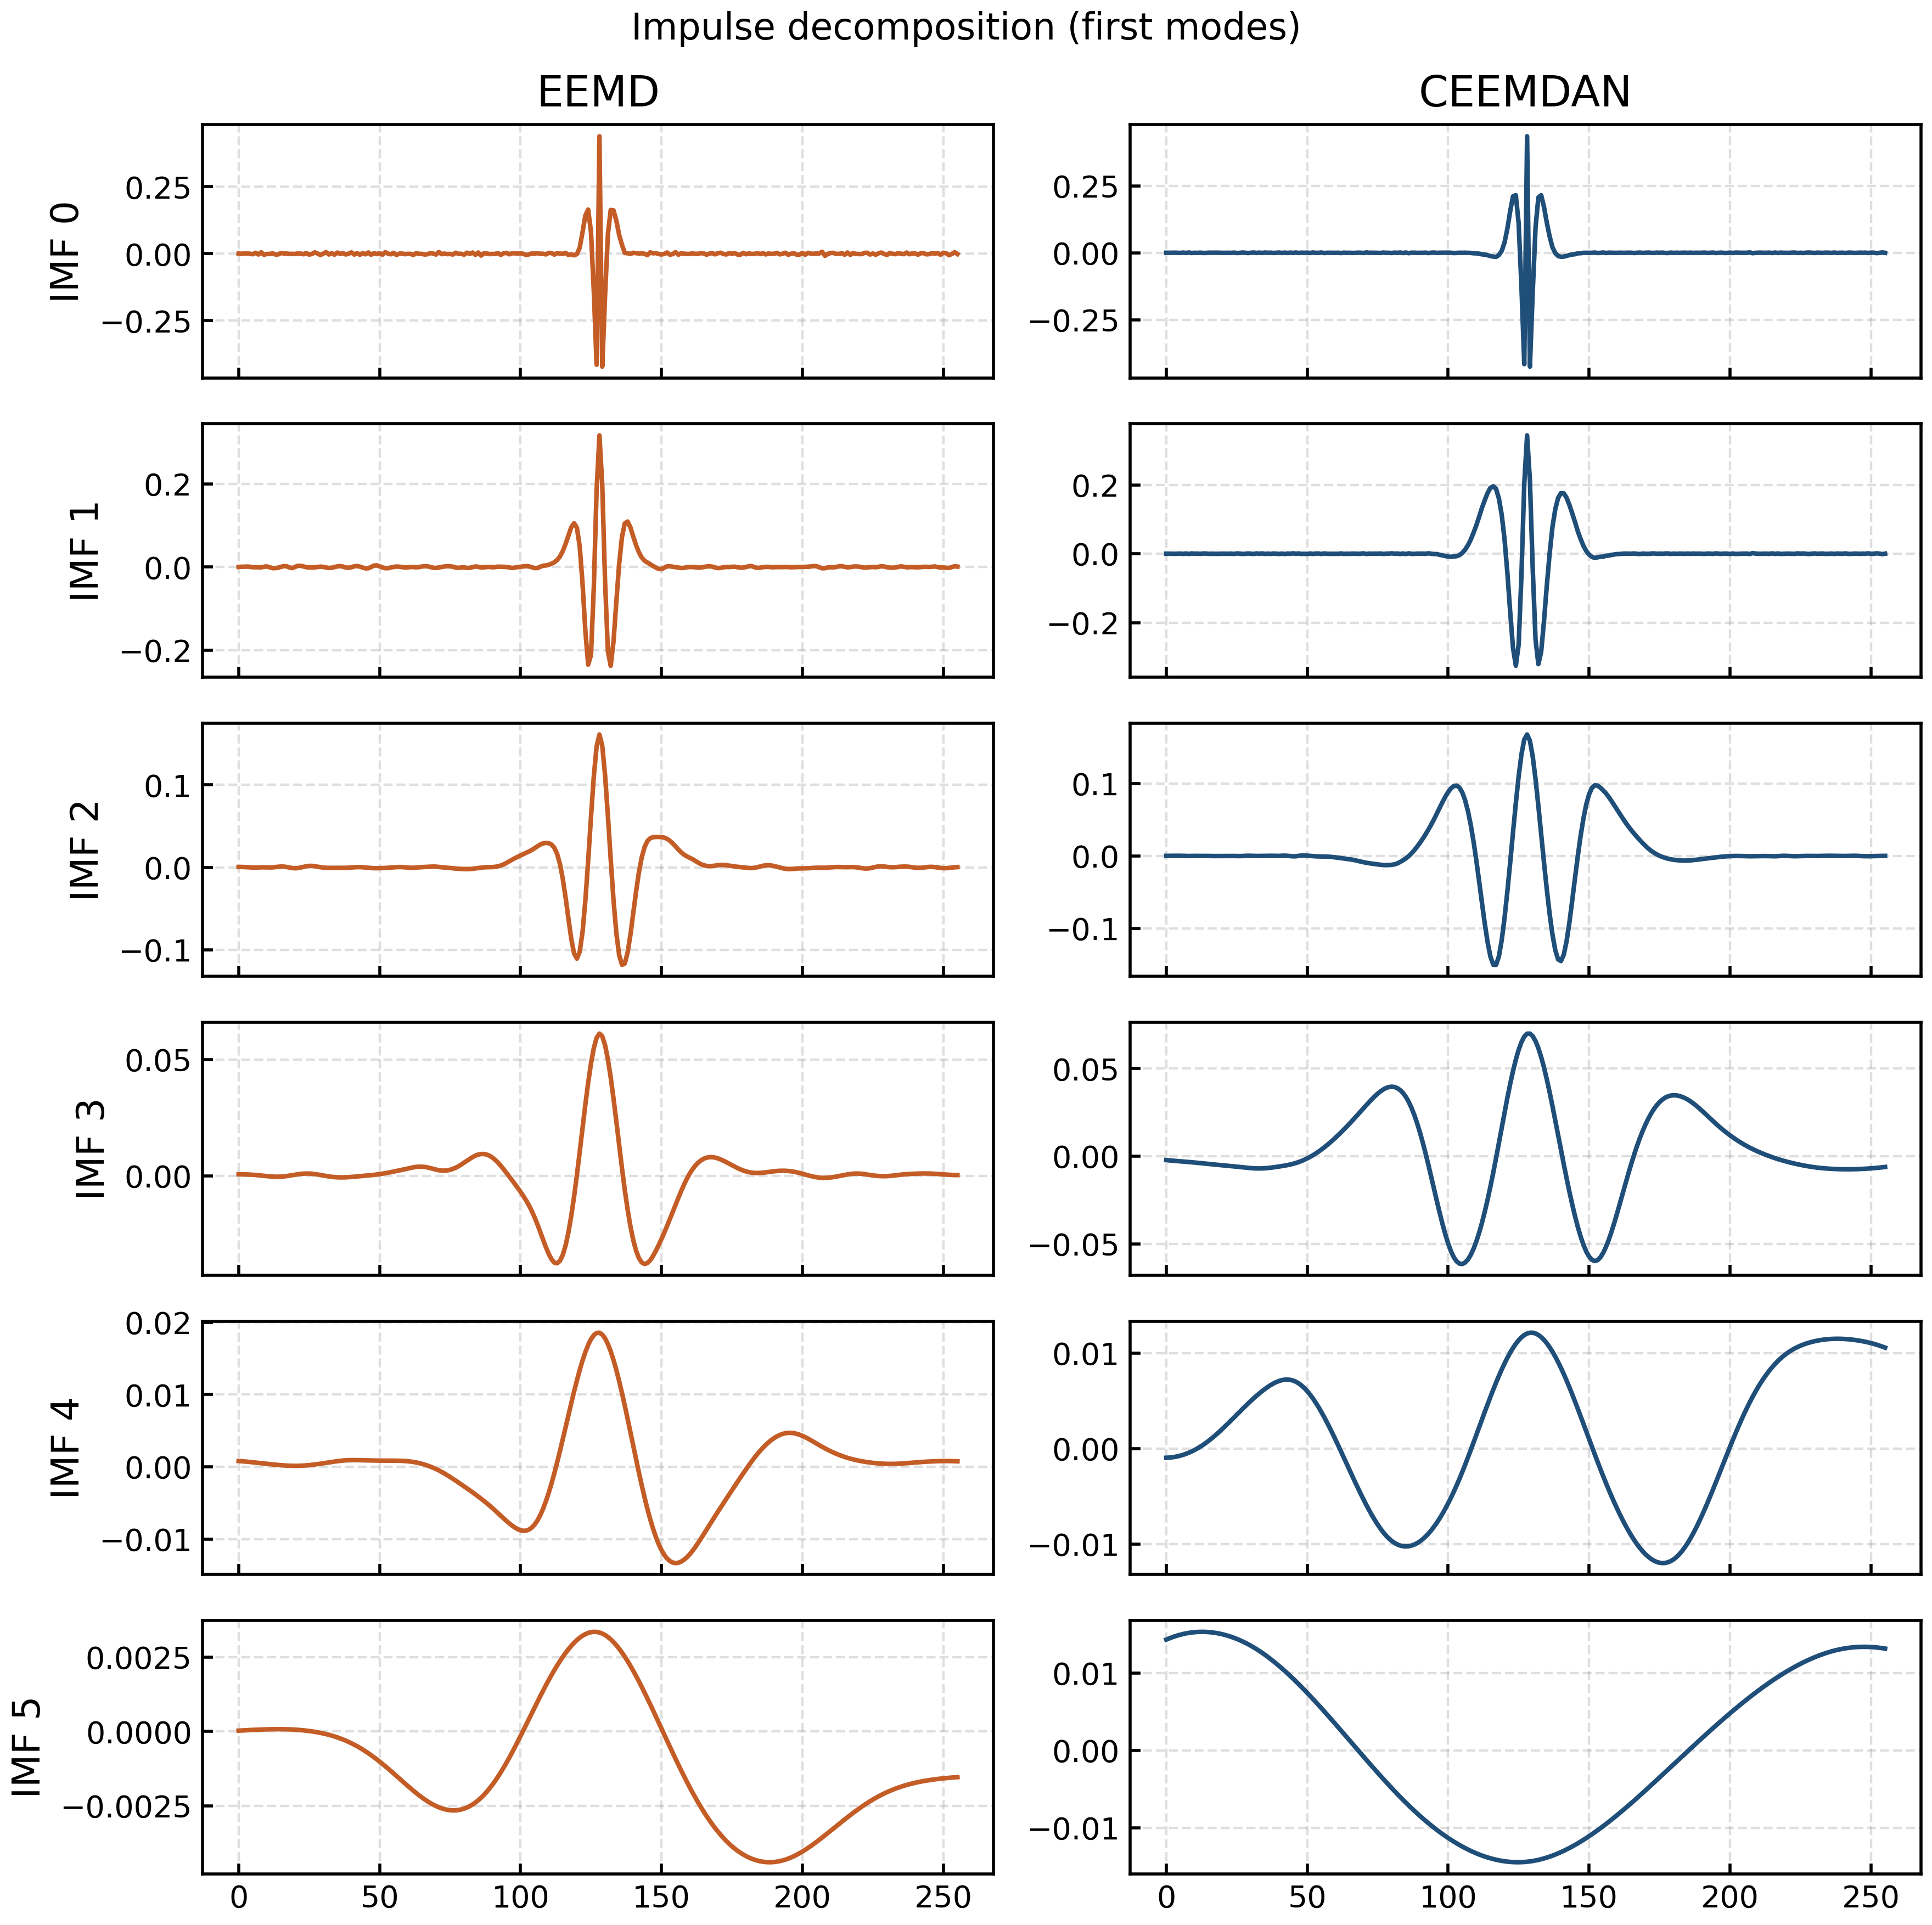

In [6]:
imp_ceemdan = CEEMDAN(
    trials=40,
    epsilon=0.05,
    noise_scale=0.02,
    max_imfs=8,
    random_seed=1,
)
cimfs = imp_ceemdan.fit_transform(impulse)

imp_eemd = EEMD(trials=40, noise_width=0.02, max_imfs=8, random_seed=1)
eimfs = imp_eemd.fit_transform(impulse)
_, e_res = imp_eemd.get_imfs_and_residue()

print(
    "CEEMDAN modes:",
    cimfs.shape[0],
    "| recon err:",
    float(np.max(np.abs(impulse - cimfs.sum(0)))),
)
print(
    "EEMD modes:",
    eimfs.shape[0],
    "| mean-only recon err:",
    float(np.max(np.abs(impulse - eimfs.sum(0)))),
    "| with residue:",
    float(np.max(np.abs(impulse - (eimfs.sum(0) + e_res)))),
)

Kshow = min(6, cimfs.shape[0], eimfs.shape[0])
fig, axes = plt.subplots(Kshow, 2, figsize=(9, 1.5 * Kshow), sharex=True)
for k in range(Kshow):
    axes[k, 0].plot(eimfs[k], color="#c45c26")
    axes[k, 0].set_ylabel(f"IMF {k}")
    axes[k, 1].plot(cimfs[k], color="#1f4e79")
    if k == 0:
        axes[k, 0].set_title("EEMD")
        axes[k, 1].set_title("CEEMDAN")
for ax in axes.ravel():
    ax.grid(True, alpha=0.25)
plt.suptitle("Impulse decomposition (first modes)")
plt.tight_layout()
plt.show()

## 6. Residue chain view

Each CEEMDAN mode is peeled from a **unique** residue.  Plotting partial
sums makes that bookkeeping visible.

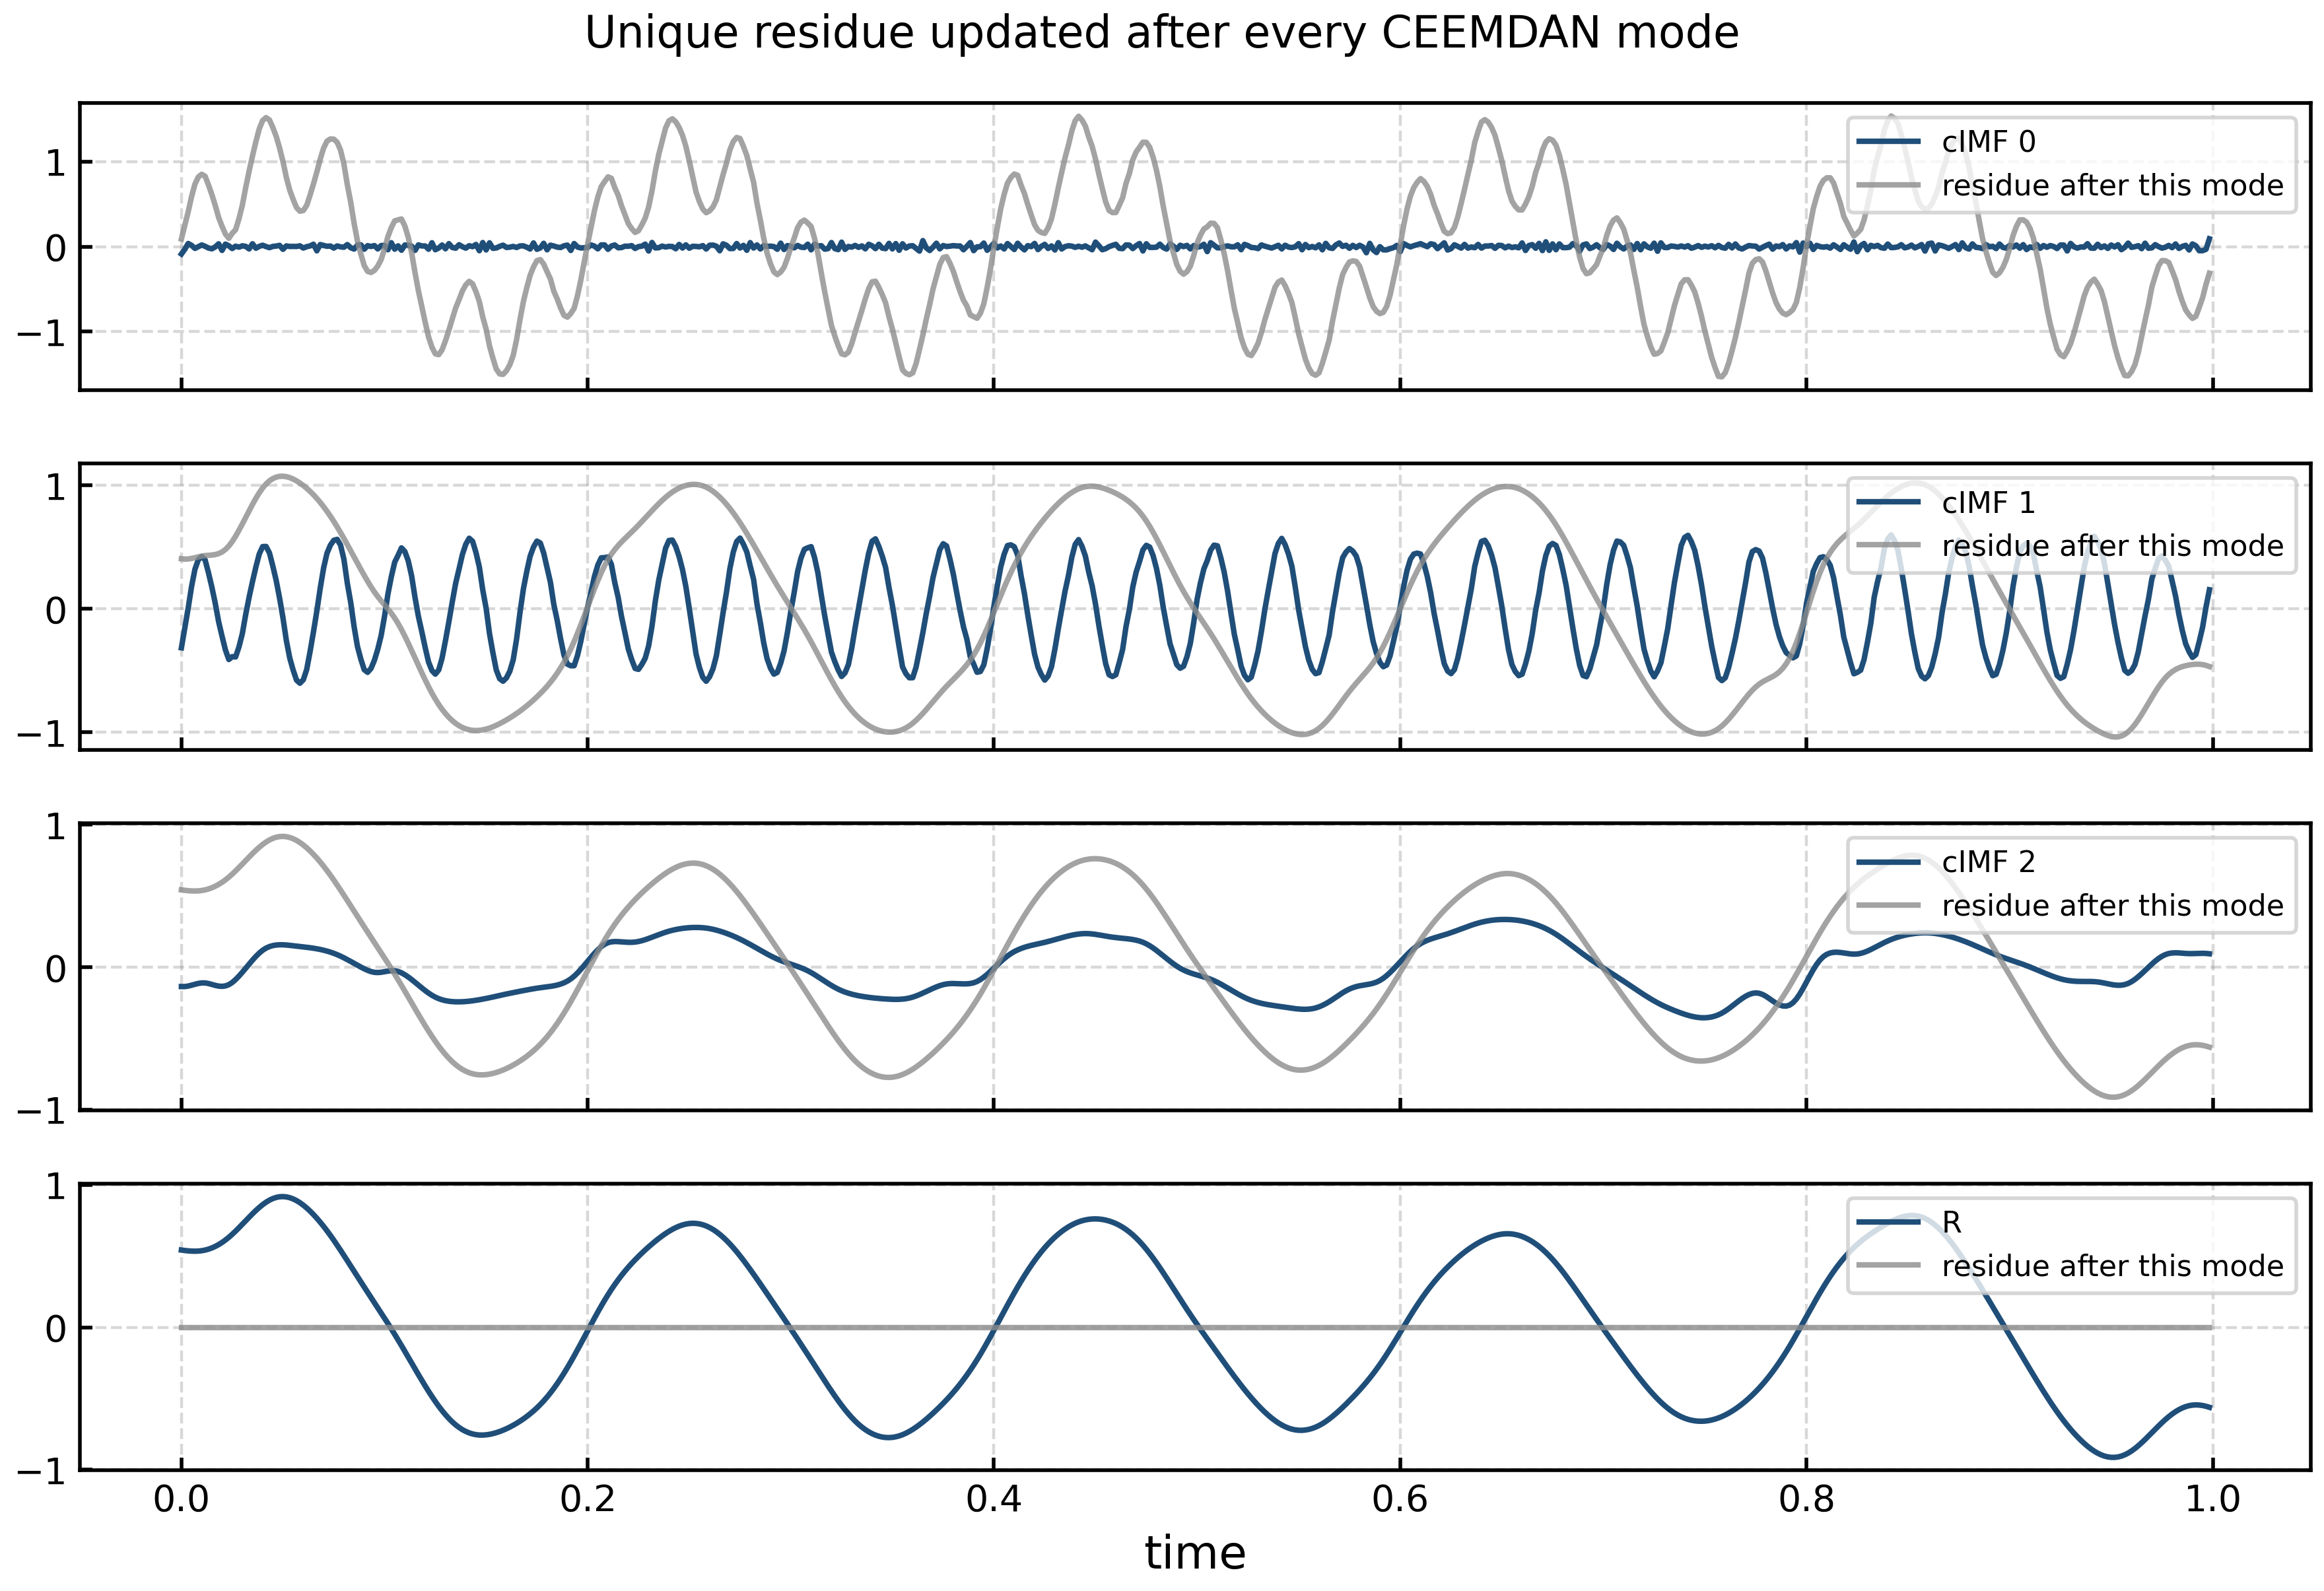

In [7]:
# Recompute on the two-tone signal with fewer modes for a cleaner panel
model = CEEMDAN(trials=25, epsilon=0.05, max_imfs=3, random_seed=2)
modes = model.fit_transform(tone, time=t)

partial = np.cumsum(modes, axis=0)
residues = tone - partial

fig, axes = plt.subplots(
    modes.shape[0], 1, figsize=(9, 1.55 * modes.shape[0]), sharex=True
)
axes = np.atleast_1d(axes)
for k, ax in enumerate(axes):
    ax.plot(
        t,
        modes[k],
        color="#1f4e79",
        label=f"cIMF {k}" if k < modes.shape[0] - 1 else "R",
    )
    ax.plot(t, residues[k], color="0.55", alpha=0.8, label="residue after this mode")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("time")
plt.suptitle("Unique residue updated after every CEEMDAN mode")
plt.tight_layout()
plt.show()

## 7. API summary

```python
from pysdkit import CEEMDAN

ceemdan = CEEMDAN(
    trials=100,
    epsilon=0.005,      # noise amplitude at each stage
    noise_scale=1.0,
    max_imfs=6,
    random_seed=42,
)
IMFs = ceemdan.fit_transform(signal)   # (K, N), last row ≈ residue
assert np.allclose(IMFs.sum(0), signal)
```

## 8. Takeaways

| | EEMD | CEEMDAN |
| --- | --- | --- |
| Noise | raw $w_i$ each full EMD | scale-matched $E_k(w_i)$ per stage |
| Residue | per-trial, then average | **unique** residue chain |
| Reconstruction | approximate | **complete** (Eq. 5) |
| Mode count | may differ across trials | consistent by construction |

Prefer CEEMDAN when you need a closed additive decomposition; keep EEMD when
you only need a quick ensemble-average denoising of EMD modes.